<a href="https://colab.research.google.com/github/the-future-codemaster/dl_lab/blob/main/Untitled51.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [55]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [56]:
# ==========================================
# Multi-Layer Perceptron (XOR Gate)
# ==========================================
class MultiLayerPerceptron:
    def __init__(self, learning_rate=0.5, epochs=4000):
        self.eta = learning_rate
        self.epochs = epochs
        np.random.seed(42)
        self.W1 = np.random.uniform(-1, 1, (2, 2))
        self.b1 = np.zeros((1, 2))
        self.W2 = np.random.uniform(-1, 1, (2, 1))
        self.b2 = np.zeros((1, 1))

    def sigmoid(self, x): return 1 / (1 + np.exp(-x))
    def sigmoid_deriv(self, x): return x * (1 - x)

    def fit(self, X, y):
        self.history = []
        y = y.reshape(-1, 1)
        self.history.append((self.W1.copy(), self.b1.copy(), self.W2.copy(), self.b2.copy(), "Initial State"))

        print("--- Training MLP for XOR Gate ---")
        save_intervals = [500, 1000, 2000, 3000, 4000]

        for epoch in range(1, self.epochs + 1):
            h_in = np.dot(X, self.W1) + self.b1
            h_out = self.sigmoid(h_in)
            out_in = np.dot(h_out, self.W2) + self.b2
            pred = self.sigmoid(out_in)

            error = y - pred
            d_pred = error * self.sigmoid_deriv(pred)
            error_h = d_pred.dot(self.W2.T)
            d_h = error_h * self.sigmoid_deriv(h_out)

            self.W2 += h_out.T.dot(d_pred) * self.eta
            self.b2 += np.sum(d_pred, axis=0, keepdims=True) * self.eta
            self.W1 += X.T.dot(d_h) * self.eta
            self.b1 += np.sum(d_h, axis=0, keepdims=True) * self.eta

            if epoch in save_intervals:
                self.history.append((self.W1.copy(), self.b1.copy(), self.W2.copy(), self.b2.copy(), f"Epoch {epoch}"))
                print(f"Epoch {epoch}: Weights updated. Saving plot state.")
                print(f"  W1: {self.W1.tolist()}, b1: {self.b1.tolist()}")
                print(f"  W2: {self.W2.tolist()}, b2: {self.b2.tolist()}")

        print("MLP Converged.\n")
        return self

The weight updates for the `MultiLayerPerceptron` happen within the `fit` method. Specifically, these lines are responsible for updating the weights and biases using backpropagation:

```python
            self.W2 += h_out.T.dot(d_pred) * self.eta
            self.b2 += np.sum(d_pred, axis=0, keepdims=True) * self.eta
            self.W1 += X.T.dot(d_h) * self.eta
            self.b1 += np.sum(d_h, axis=0, keepdims=True) * self.eta
```

Here's a breakdown:
- `d_pred` and `d_h` represent the error gradients for the output layer and hidden layer, respectively.
- `h_out` is the output of the hidden layer.
- `X` is the input data.
- `self.eta` is the learning rate.

These lines apply the gradient descent update rule to adjust the weights (`W1`, `W2`) and biases (`b1`, `b2`) in the direction that minimizes the error.

--- Training MLP for XOR Gate ---
Epoch 500: Weights updated. Saving plot state.
  W1: [[-0.3398150557260002, 0.8714309152028622], [0.5313273218993088, -0.21746157775534442]], b1: [[0.17326800588598038, -0.0005614369194368611]]
  W2: [[-0.4755206187641375], [-0.3409606918904791]], b2: [[0.4639598091850209]]
Epoch 1000: Weights updated. Saving plot state.
  W1: [[-0.9122347480207456, 1.3773248579945274], [1.2093366276801425, -0.8221042975787322]], b1: [[0.7383336578689819, 0.532532029946206]]
  W2: [[-0.8214271937391453], [-0.7240869555429761]], b2: [[1.0219501776470181]]
Epoch 2000: Weights updated. Saving plot state.
  W1: [[-5.157362506406373, 5.330319081235029], [5.345820483237454, -5.112637205168626]], b1: [[2.6493505565963438, 2.616237420154759]]
  W2: [[-5.521018748250543], [-5.524023926083079]], b2: [[8.067613361207112]]
Epoch 3000: Weights updated. Saving plot state.
  W1: [[-5.710082927544085, 5.884765503570765], [5.898280753837026, -5.676614952642683]], b1: [[2.91213782218812

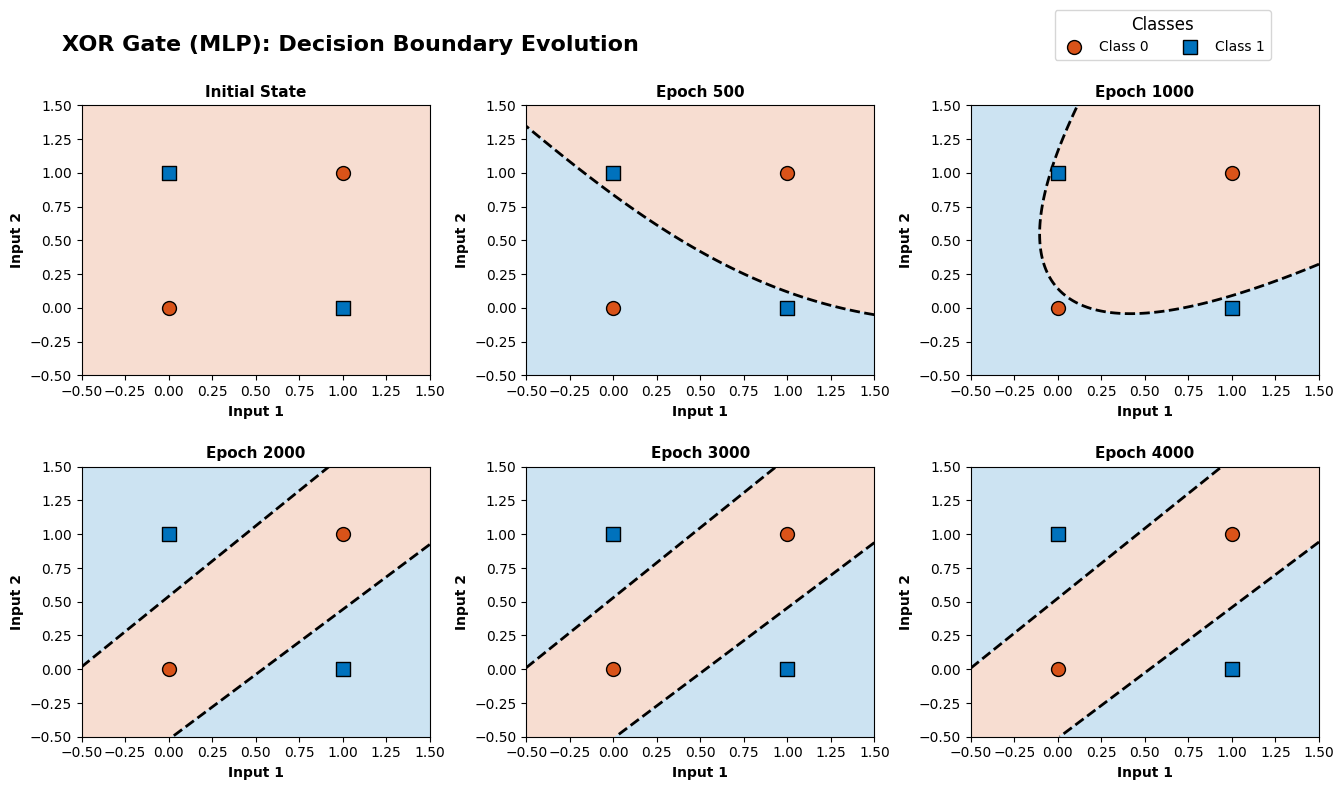

In [57]:
def add_global_legend(fig):
    handles = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#D95319', markersize=10, label='Class 0', markeredgecolor='k'),
        plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='#0072BD', markersize=10, label='Class 1', markeredgecolor='k')
    ]
    fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(0.95, 0.99), title='Classes', fontsize=10, title_fontsize=12, frameon=True, ncol=2)

def plot_mlp_decision_boundaries(X, y, history, gate_name, filename):
    num_plots = len(history)
    cols = 3
    rows = math.ceil(num_plots / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols*4.5, rows*4.0))
    fig.suptitle(f'{gate_name} Gate (MLP): Decision Boundary Evolution', fontweight='bold', fontsize=16, x=0.05, ha='left', y=0.95)

    add_global_legend(fig)
    axes = np.array(axes).flatten() if num_plots > 1 else [axes]

    # Solid pastel colors to bypass EPS transparency limitations
    light_orange = '#F7DDD1'
    light_blue = '#CCE3F2'

    for i, (W1, b1, W2, b2, title) in enumerate(history):
        ax = axes[i]

        x1_min, x1_max = -0.5, 1.5
        ax.set_xlim(x1_min, x1_max)
        ax.set_ylim(-0.5, 1.5)

        xx, yy = np.meshgrid(np.linspace(x1_min, x1_max, 100), np.linspace(-0.5, 1.5, 100))
        grid = np.c_[xx.ravel(), yy.ravel()]

        h = 1 / (1 + np.exp(-(np.dot(grid, W1) + b1)))
        out = 1 / (1 + np.exp(-(np.dot(h, W2) + b2)))
        Z = out.reshape(xx.shape)

        # Plot filled contour using solid pastel colors (alpha=1.0)
        ax.contourf(xx, yy, Z, levels=[0, 0.5, 1], colors=[light_orange, light_blue], alpha=1.0, zorder=1)
        ax.contour(xx, yy, Z, levels=[0.5], colors='k', linestyles='--', linewidths=2, zorder=2)

        # Plot points on top
        for label, marker, color in zip([0, 1], ['o', 's'], ['#D95319', '#0072BD']):
            ax.scatter(X[y == label, 0], X[y == label, 1], marker=marker, color=color, edgecolors='k', s=100, zorder=3)

        ax.set_title(title, fontweight='bold', fontsize=11)
        ax.set_xlabel('Input 1', fontweight='bold')
        ax.set_ylabel('Input 2', fontweight='bold')

    for j in range(i + 1, len(axes)): fig.delaxes(axes[j])

    plt.tight_layout(rect=[0, 0, 1, 0.95], h_pad=2.0, w_pad=1.0)
    plt.savefig(filename, format='eps', dpi=600, bbox_inches='tight')
    plt.show()

# 4. XOR Gate (MLP)
X_xor = np.array([[0,0], [0,1], [1,0], [1,1]])
y_xor = np.array([0, 1, 1, 0])
model_xor = MultiLayerPerceptron(learning_rate=0.5, epochs=4000).fit(X_xor, y_xor)
plot_mlp_decision_boundaries(X_xor, y_xor, model_xor.history, "XOR", "XOR_Gate_MLP.eps")